#  Tester  (28×28)

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

import torch
import keras
import numpy as np
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import v2
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt

NUM_CLASSES = 62 

class EMNISTModel(keras.Model):
#CNN compact pour EMNIST 28×28 → 62 classes.

    def __init__(self, num_classes: int = NUM_CLASSES):
        super().__init__()

        # Bloc convolutif 1 : 1 → 32
        self.conv1 = keras.layers.Conv2D(32, kernel_size=10, padding="same", activation="relu")
        self.bn1   = keras.layers.BatchNormalization()
        self.pool1 = keras.layers.MaxPooling2D(pool_size=2)  # 28 → 14

        # Bloc convolutif 2 : 32 → 64
        self.conv2 = keras.layers.Conv2D(64, kernel_size=5, padding="same", activation="relu")
        self.bn2   = keras.layers.BatchNormalization()
        self.pool2 = keras.layers.MaxPooling2D(pool_size=2)  # 14 → 7

        # Bloc convolutif 3 : 64 → 128  
        self.conv3 = keras.layers.Conv2D(128, kernel_size=3, padding="same", activation="relu")
        self.bn3   = keras.layers.BatchNormalization()

        # Tête de classification
        self.flatten  = keras.layers.Flatten()               # 7×7×128 = 6272
        self.dropout  = keras.layers.Dropout(0.2)
        self.fc1      = keras.layers.Dense(7*128, activation="relu")
        self.fc2      = keras.layers.Dense(128, activation="relu")
        self.fc3      = keras.layers.Dense(num_classes)       # logits (pas de softmax)

    def call(self, x, training=False):
        # x : (batch, 1, 28, 28)  →  Keras attend (batch, H, W, C)
        x = keras.ops.transpose(x, axes=(0, 2, 3, 1))

        x = self.pool1(self.bn1(self.conv1(x), training=training))
        x = self.pool2(self.bn2(self.conv2(x), training=training))
        x = self.bn3(self.conv3(x), training=training)

        x = self.flatten(x)
        x = self.dropout(x, training=training)
        x = self.fc1(x)
        x = self.fc2(x)
        return self.fc3(x)


def load_model(weights_path: str = "best_emnist_model.weights.h5") -> keras.Model:

    model = EMNISTModel()

    # Build du modèle avec un tensor factice pour initialiser les poids
    dummy = torch.zeros(1, 1, 28, 28)
    model(dummy)

    model.load_weights(weights_path)
    model.trainable = False  # mode inférence uniquement
    print(f"✅ Modèle chargé depuis '{weights_path}'")

    return model


# ------------------------------------------------------------------ #
#  CLASSES EMNIST (pour les labels)
# ------------------------------------------------------------------ #
def load_classes() -> list:
    """Récupère la liste des 62 classes EMNIST byclass."""
    dataset = EMNIST(root="data", split="byclass", train=False, download=True)
    return dataset.classes


model   = load_model("best_emnist_model.weights.h5")
CLASSES = load_classes()

✅ Modèle chargé depuis 'best_emnist_model.weights.h5'


In [ ]:
import torch
import numpy as np
import torch.nn.functional as F
from PIL import Image
from torchvision.transforms import v2

transform = v2.Compose([
    v2.ToImage(),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.1307], std=[0.3081])
])

# ------------------------------------------------------------------ #
#  FONCTION 1 : PNG → tensor prêt pour le modèle
# ------------------------------------------------------------------ #

def preprocess_image(path: str) -> torch.Tensor:
    """
    Charge une image de n'importe quelle taille et la convertit
    en tensor 28x28 normalisé, en préservant le ratio du caractère.

    Args:
        path : chemin vers l'image

    Returns:
        tensor de shape (1, 1, 28, 28) prêt pour le modèle
    """
    img = Image.open(path).convert("L")  # niveaux de gris

    arr = np.array(img)

    # --- Inverser si fond blanc / caractère noir ---
    if arr.mean() > 127:
        arr = 255 - arr

    # --- Recadrer autour du caractère (supprimer le fond vide) ---
    # Trouver les lignes et colonnes qui contiennent du contenu
    rows    = np.any(arr > 30, axis=1)  # lignes non vides
    cols    = np.any(arr > 30, axis=0)  # colonnes non vides

    if rows.any() and cols.any():
        row_min, row_max = np.where(rows)[0][[0, -1]]
        col_min, col_max = np.where(cols)[0][[0, -1]]
        arr = arr[row_min:row_max+1, col_min:col_max+1]  # crop serré

    # --- Ajouter une marge autour du caractère (comme EMNIST) ---
    MARGIN = 4  # pixels de marge sur chaque côté (sur base 28x28)
    h, w   = arr.shape
    ratio  = (28 - 2 * MARGIN) / max(h, w)  # ratio pour tenir dans 20x20
    new_h  = max(1, int(h * ratio))
    new_w  = max(1, int(w * ratio))

    # Redimensionner en gardant le ratio
    img_cropped  = Image.fromarray(arr)
    img_resized  = img_cropped.resize((new_w, new_h), Image.LANCZOS)
    arr_resized  = np.array(img_resized)

    # --- Centrer sur un canvas noir 28x28 ---
    canvas = np.zeros((28, 28), dtype=np.uint8)
    y_off  = (28 - new_h) // 2
    x_off  = (28 - new_w) // 2
    canvas[y_off:y_off+new_h, x_off:x_off+new_w] = arr_resized

    # --- Normalisation identique à l'entraînement ---
    tensor = transform(Image.fromarray(canvas))  # (1, 28, 28)
    tensor = tensor.unsqueeze(0)                 # (1, 1, 28, 28)

    return tensor

def preprocess_image_28x28(path: str) -> torch.Tensor:
    """
    Charge un PNG 28x28 et le convertit en tensor normalisé.
    
    Args:
        path : chemin vers l'image (.png, .jpg, etc.)
    
    Returns:
        tensor de shape (1, 1, 28, 28) prêt pour le modèle
    """
    # Charger en niveaux de gris
    img = Image.open(path).convert("L")

    # Redimensionner si nécessaire
    if img.size != (28, 28):
        img = img.resize((28, 28), Image.LANCZOS)

    arr = np.array(img)

    # EMNIST : fond noir, caractère blanc → inverser si besoin
    if arr.mean() > 127:
        arr = 255 - arr

    # Appliquer la transformation (ToImage + Normalize)
    tensor = transform(Image.fromarray(arr))  # (1, 28, 28)
    tensor = tensor.unsqueeze(0)              # (1, 1, 28, 28)

    return tensor

# ------------------------------------------------------------------ #
#  FONCTION 2 : tensor → prédiction
# ------------------------------------------------------------------ #
def predict(tensor: torch.Tensor, top_k: int = 5) -> list[tuple[str, float]]:
    """
    Prédit le caractère à partir d'un tensor normalisé.
    
    Args:
        tensor : shape (1, 1, 28, 28), sorti de preprocess_image()
        top_k  : nombre de prédictions retournées (défaut 5)
    
    Returns:
        liste de tuples (classe, confiance%) triée par confiance décroissante
        ex: [('a', 92.3), ('d', 4.1), ('o', 1.8), ...]
    """
    device = next(model.parameters()).device  # GPU ou CPU selon le modèle
    tensor = tensor.to(device)

    with torch.no_grad():
        logits = model(tensor, training=False)
        probs  = F.softmax(logits, dim=1).cpu().squeeze()

    top_probs, top_idx = probs.topk(top_k)

    return [
        (CLASSES[i.item()], round(p.item() * 100, 2))
        for i, p in zip(top_idx, top_probs)
    ]



# ------------------------------------------------------------------ #
#  FONCTION PRINCIPALE : chemin → prédiction (combine les deux)
# ------------------------------------------------------------------ #
def predict_from_image(path: str, top_k: int = 5, methode=preprocess_image) -> list[tuple[str, float]]:

    tensor = methode(path)

    results = predict(tensor, top_k=top_k)

    print(f"Image : {path}")
    print(f"  → Prédit : '{results[0][0]}'  ({results[0][1]}%)")
    print(f"  → Top-{top_k} : {results}")

    return results

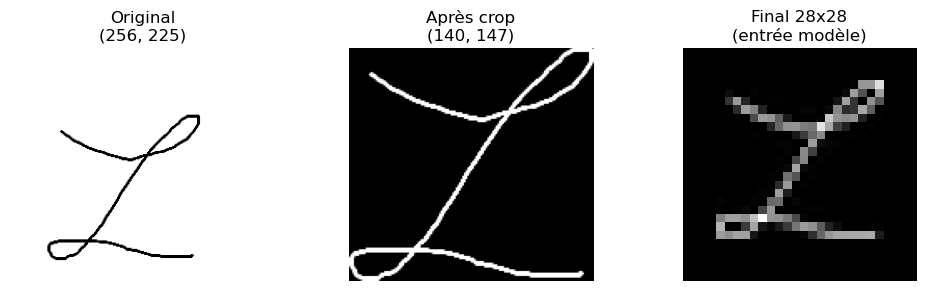

In [36]:
def debug_preprocess(path: str):
    """Affiche les étapes intermédiaires du preprocessing."""
    img = Image.open(path).convert("L")
    arr = np.array(img)
    if arr.mean() > 127:
        arr = 255 - arr

    rows = np.any(arr > 30, axis=1)
    cols = np.any(arr > 30, axis=0)
    row_min, row_max = np.where(rows)[0][[0, -1]]
    col_min, col_max = np.where(cols)[0][[0, -1]]
    arr_crop = arr[row_min:row_max+1, col_min:col_max+1]

    tensor = preprocess_image(path)
    arr_final = tensor.squeeze().numpy()

    fig, axes = plt.subplots(1, 3, figsize=(10, 3))
    axes[0].imshow(np.array(Image.open(path).convert("L")), cmap="gray")
    axes[0].set_title(f"Original\n{Image.open(path).size}")
    axes[1].imshow(arr_crop, cmap="gray")
    axes[1].set_title(f"Après crop\n{arr_crop.shape}")
    axes[2].imshow(arr_final, cmap="gray")
    axes[2].set_title("Final 28x28\n(entrée modèle)")
    for ax in axes:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

# Utilisation :
debug_preprocess("myletter/l.png")

In [37]:
path="myletter/L.png"
img=Image.open(path)
methode=preprocess_image
if img.size == (28,28):
    methode=preprocess_image_28x28
print(f"Image size: {img.size}, using {methode}()")

# Pipeline complet en un appel
#predict_from_image("lettre.png",methode=methode)

# Ou étape par étape si tu veux inspecter le tensor
tensor  = methode(path)
results = predict(tensor, top_k=5)
print(results)

# Accéder juste à la meilleure prédiction
#best_class, confidence = predict_from_image("lettre.png")[0]
#print(f"Caractère : {best_class}, confiance : {confidence}%")

Image size: (256, 225), using <function preprocess_image at 0x000001471DED27A0>()
[('1', 51.63), ('I', 40.79), ('l', 4.24), ('5', 0.73), ('E', 0.67)]
